55398 23742 (55398, 10) (23742, 10)
55398 23742
            MaxTemp       MinTemp       Temp9am       Temp3pm   Pressure3pm  \
count  55398.000000  55398.000000  55398.000000  55398.000000  55398.000000   
mean      23.632528     12.626672     17.427364     22.106719   1015.091287   
std        6.964157      6.223687      6.340894      6.814940      6.976438   
min        2.600000     -7.000000     -3.100000      2.300000    978.200000   
25%       18.200000      8.100000     12.700000     16.900000   1010.400000   
50%       23.100000     12.400000     17.000000     21.600000   1015.100000   
75%       28.600000     17.200000     22.000000     26.800000   1019.800000   
max       48.100000     33.900000     40.200000     46.700000   1039.600000   

        Pressure9am  WindGustSpeed  WindSpeed3pm  WindSpeed9am     RainToday  
count  55398.000000   55398.000000  55398.000000  55398.000000  55398.000000  
mean    1017.471504      40.747680     19.492274     15.175421      0.356890  
std

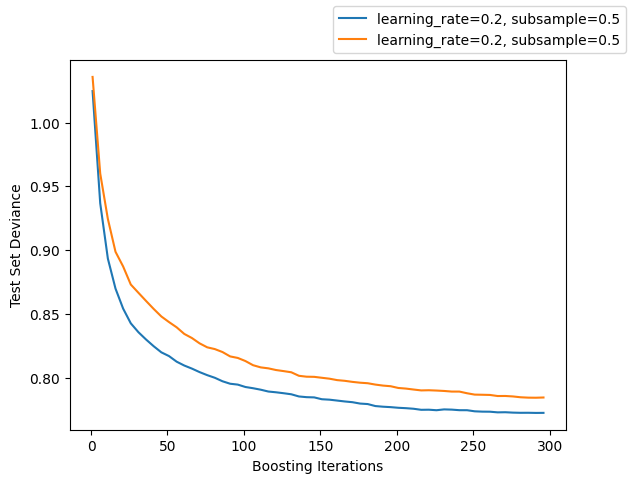

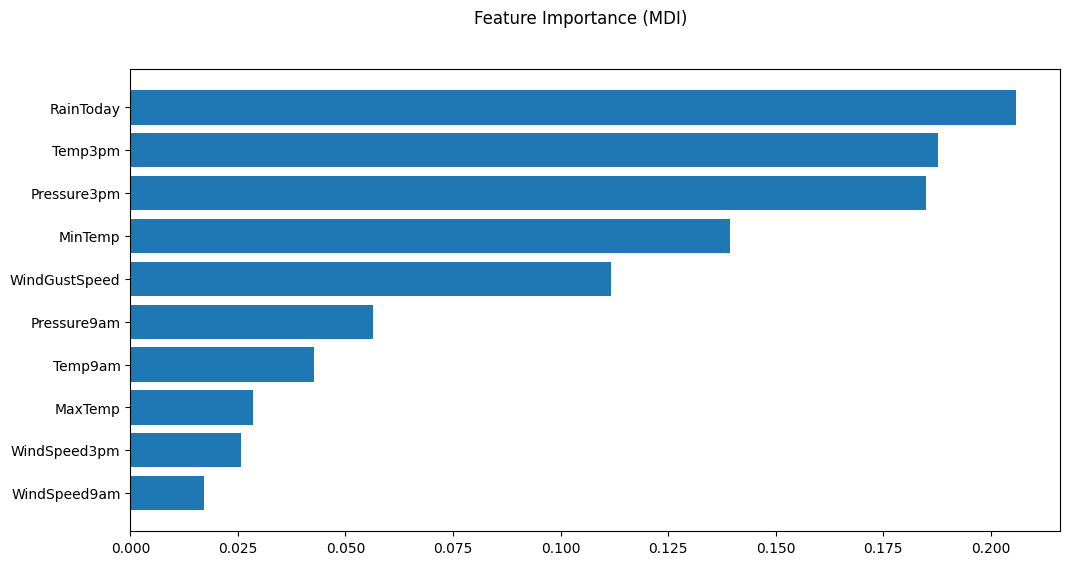

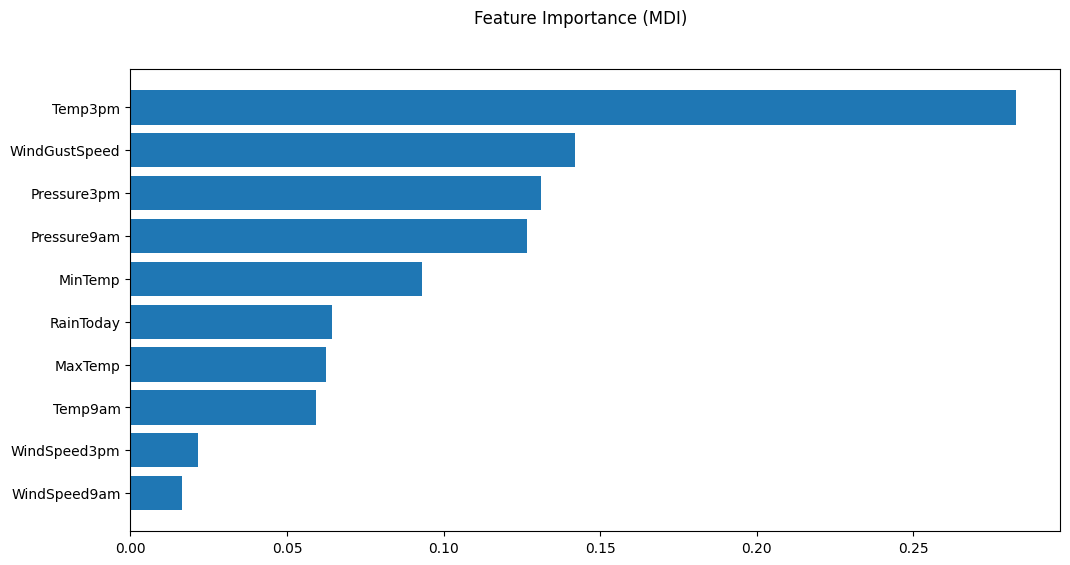

In [ ]:
import dataclasses
from typing import Dict, List

from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from src.classifier.gradient_boosting import RegressionConfig, prepare_data
from src.utils import get_raw_results, res_raw
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import numpy as np

from sklearn import ensemble
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split


config = RegressionConfig(
    max_leaf_nodes=4,
    min_samples_split=5,
    test_size=0.3,
    n_estimators=300,
    max_depth=None,
    subsample=0.5,
    learning_rate=0.2,
)

cleaned_data, polluted_data, polluted_dq, polluted_certainty = prepare_data(config)


# https://scikit-learn.org/stable/auto_examples/ensemble/plot_gradient_boosting_regression.html
def plot_feature_importance(clf: ensemble.GradientBoostingClassifier, feature_names):
    feature_importance = clf.feature_importances_
    sorted_idx = np.argsort(feature_importance)
    pos = np.arange(sorted_idx.shape[0]) + 0.5
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(pos, feature_importance[sorted_idx], align="center")
    ax.set_yticks(pos, feature_names[sorted_idx])
    fig.suptitle("Feature Importance (MDI)")
    return fig


results = {}


# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause
# https://scikit-learn.org/stable/auto_examples/ensemble/plot_gradient_boosting_regularization.html#sphx-glr-auto-examples-ensemble-plot-gradient-boosting-regularization-py

X_c, y_c = cleaned_data.drop("RainTomorrow", axis=1), cleaned_data["RainTomorrow"]
X_p, y_p = polluted_data.drop("RainTomorrow", axis=1), polluted_data["RainTomorrow"]

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c,
    y_c,
    test_size=config.test_size,
    random_state=config.random_state,
)
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_p,
    y_p,
    test_size=config.test_size,
    random_state=config.random_state,
)

original_params: Dict[str, float | None] = {
    "n_estimators": 300,
    "max_leaf_nodes": 4,
    "max_depth": None,
    "random_state": 2,
    "min_samples_split": 5,
}

loss_fig, loss_fig_ax = plt.subplots()

for label, color, setting in [
    # ("No shrinkage", "orange", {"learning_rate": 1.0, "subsample": 1.0}),
    # ("learning_rate=0.2", "turquoise", {"learning_rate": 0.2, "subsample": 1.0}),
    # ("subsample=0.5", "blue", {"learning_rate": 1.0, "subsample": 0.5}),
    (
        "learning_rate=0.2, subsample=0.5",
        "gray",
        {"learning_rate": 0.2, "subsample": 0.5},
    ),
    # (
    #     "learning_rate=0.2, max_features=2",
    #     "magenta",
    #     {"learning_rate": 0.2, "max_features": 2},
    # ),
]:
    for X_train, y_train, X_test, y_test in [
        (X_c_train, y_c_train, X_c_test, y_c_test),
        (X_p_train, y_p_train, X_c_test, y_c_test),
    ]:
        scaler = StandardScaler()
        scaler.fit(X_train)

        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        params = dict(original_params)
        params.update(setting)

        clf = ensemble.GradientBoostingClassifier(**params)  # type: ignore
        clf.fit(X_train_scaled, y_train)

        # compute test set deviance
        test_deviance = np.zeros((params["n_estimators"],), dtype=np.float64)

        for i, y_proba in enumerate(clf.staged_predict_proba(X_test_scaled)):
            test_deviance[i] = 2 * log_loss(y_test, y_proba[:, 1])

        loss_fig_ax.plot(
            (np.arange(test_deviance.shape[0]) + 1)[::5],
            test_deviance[::5],
            "-",
            label=label,
        )
        plot_feature_importance(clf, X_c.columns)

    loss_fig.legend(loc="upper right")
    loss_fig_ax.set_xlabel("Boosting Iterations")
    loss_fig_ax.set_ylabel("Test Set Deviance")
None

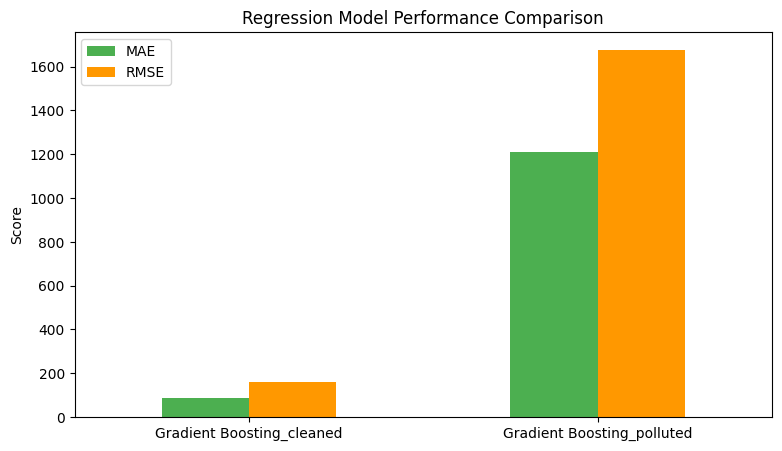

In [18]:
import dataclasses
from typing import Dict, List

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from src.classifier.gradient_boosting import RegressionConfig, prepare_data
from src.utils import get_raw_results, res_raw
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import numpy as np

from sklearn import ensemble
from sklearn.metrics import f1_score, log_loss, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


config = RegressionConfig(
    max_leaf_nodes=4,
    min_samples_split=5,
    test_size=0.3,
    n_estimators=300,
    max_depth=None,
    subsample=0.5,
    learning_rate=0.2,
    cols=["QUANTITYORDERED", "PRICEEACH", "ORDERLINENUMBER", "SALES", "MSRP"],
)

df_raw = get_raw_results()

cleaned_results = df_raw[
    (df_raw["dataset"] == "auto_sales")
    & (df_raw["metric"] == "completeness_nullAndDMVRatio")
    & (df_raw["type"] == "cleaned")
]
polluted_results = df_raw[
    (df_raw["dataset"] == "auto_sales")
    & (df_raw["metric"] == "consistency_ruleBasedPipino")
    & (df_raw["dimension"] == "consistency_tuple")
    & (df_raw["type"] == "polluted")
    & (df_raw["pollution_mechanism"] == "ECAR")
    & (df_raw["pollution_rate"] == 0.35)
]

cleaned_data = pd.DataFrame(
    {res["column"]: res["result"].data for _, res in cleaned_results.iterrows()}
)[config.cols]

assert len(polluted_results) == 1, polluted_results

polluted_data = pd.DataFrame(
    polluted_results.iloc[0]["result"].data,
    columns="ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE".split(
        ","
    ),
)[config.cols]

polluted_dq = pd.Series(
    polluted_results.iloc[0]["result"].dq_result,
)
polluted_certainty = pd.Series(
    polluted_results.iloc[0]["result"].certainty,
)

target_column = "SALES"

X_c, y_c = cleaned_data.drop(target_column, axis=1), cleaned_data[target_column]
X_p, y_p = polluted_data.drop(target_column, axis=1), polluted_data[target_column]

cat_features = X_c.select_dtypes(include=["object"]).columns.tolist()
num_features = X_c.select_dtypes(include=["number"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            cat_features,
        ),
        ("num", "passthrough", num_features),
    ]
)

models = {
    # "Linear Regression": LinearRegression(),
    "Gradient Boosting": ensemble.GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, random_state=42, max_leaf_nodes=4, min_samples_split=5
    ),
}

results = {}


X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c,
    y_c,
    test_size=config.test_size,
    random_state=config.random_state,
)
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_p,
    y_p,
    test_size=config.test_size,
    random_state=config.random_state,
)

X, y = X_c, y_c


original_params: Dict[str, float | None] = {
    "n_estimators": 300,
    "max_leaf_nodes": 4,
    "max_depth": None,
    "random_state": 2,
    "min_samples_split": 5,
}


# https://scikit-learn.org/stable/auto_examples/ensemble/plot_gradient_boosting_regression.html
def plot_feature_importance(clf: ensemble.GradientBoostingRegressor):
    feature_importance = clf.feature_importances_
    sorted_idx = np.argsort(feature_importance)
    pos = np.arange(sorted_idx.shape[0]) + 0.5
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(pos, feature_importance[sorted_idx], align="center")
    ax.set_yticks(pos, sorted_idx)
    fig.suptitle("Feature Importance (MDI)")
    return fig


for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])

    for (X_train, y_train, X_test, y_test), data_key in [
        ((X_c_train, y_c_train, X_c_test, y_c_test), "cleaned"),
        ((X_p_train, y_p_train, X_c_test, y_c_test), "polluted"),
    ]:
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        results[name + "_" + data_key] = {
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        }
        # plot_feature_importance(model)

results_df = pd.DataFrame(results).T

results_df.plot(kind="bar", figsize=(9, 5), color=["#4CAF50", "#FF9800", "#03A9F4"])

plt.title("Regression Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

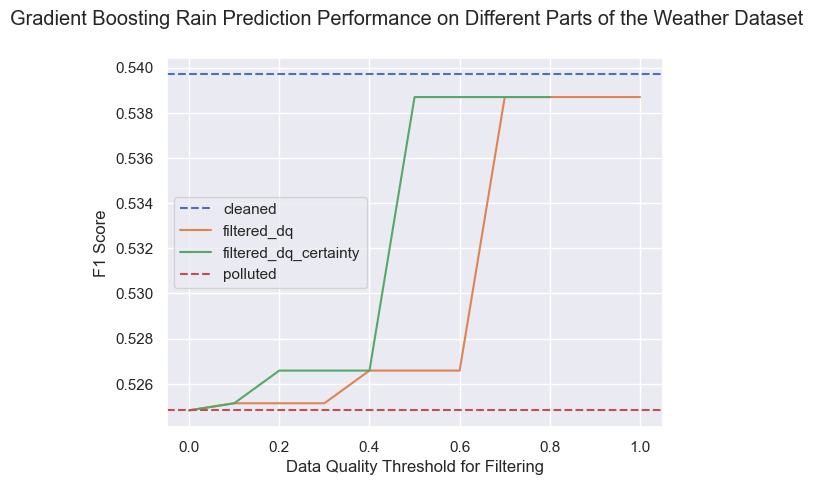

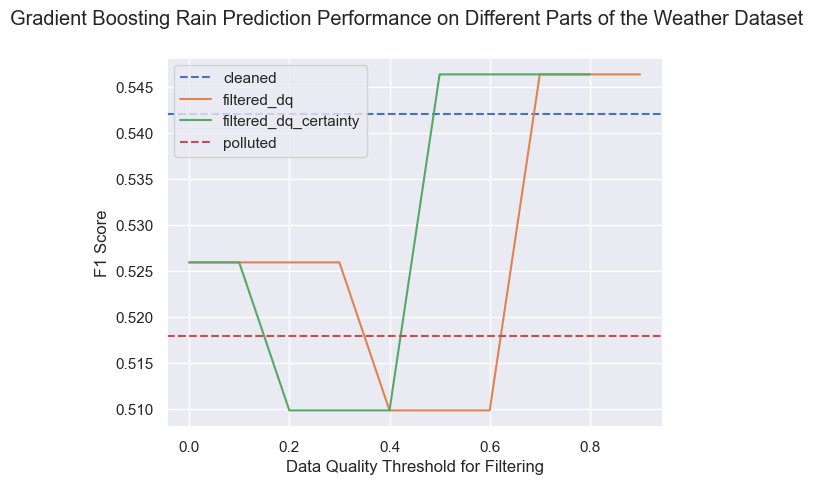

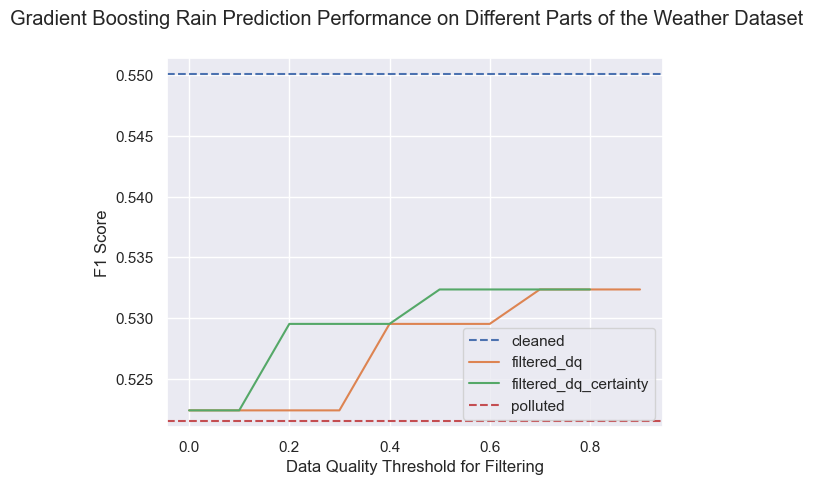

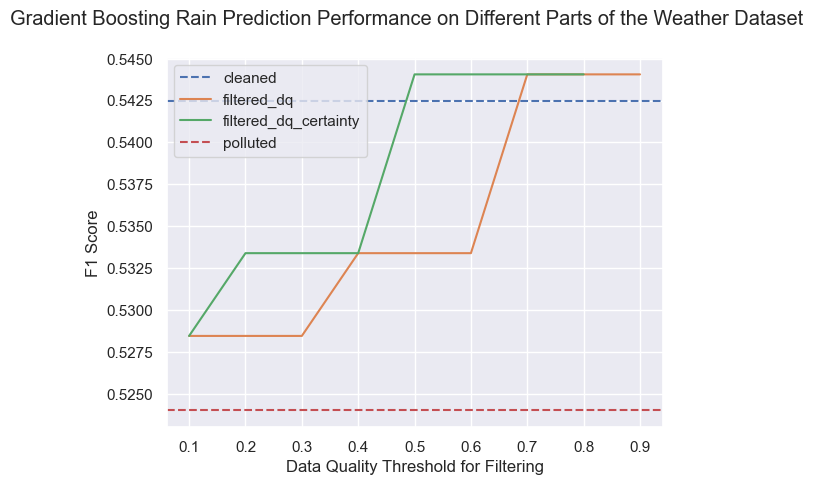

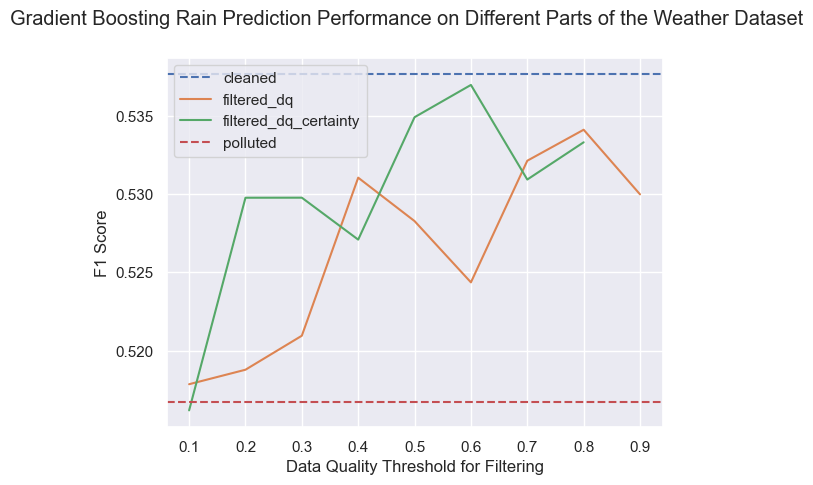

In [ ]:
from pathlib import Path
from click import group
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

sns.set_theme()

results_path = Path("regression-results")
for folder in sorted(results_path.glob("*"), reverse=True):
    if not (folder / "results.csv").exists():
        continue
    df = pd.read_csv(folder / "results.csv")

    fig, ax = plt.subplots()
    for i, (data, group) in enumerate(df.groupby("data")):
        mean_scores = group.groupby("threshold", dropna=False)["score"].mean()
        if all(mean_scores.index.isna()):
            ax.axhline(
                mean_scores.iloc[0], color=f"C{i}", linestyle="--", label=f"{data}"
            )
        else:
            mean_scores.plot(ax=ax, color=f"C{i}", label=f"{data}")

    ax.legend()
    ax.set_ylabel("F1 Score")
    ax.set_xlabel("Data Quality Threshold for Filtering")
    fig.suptitle(
        f"Gradient Boosting Rain Prediction Performance on Different Parts of the Weather Dataset"
    )
    fig.savefig(folder / "plot.png", bbox_inches="tight")

In [14]:
from sklearn.metrics import accuracy_score, classification_report

print(accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred))

0.8513393985342431
              precision    recall  f1-score   support

         0.0       0.87      0.95      0.91     12340
         1.0       0.74      0.50      0.60      3488

    accuracy                           0.85     15828
   macro avg       0.80      0.73      0.75     15828
weighted avg       0.84      0.85      0.84     15828



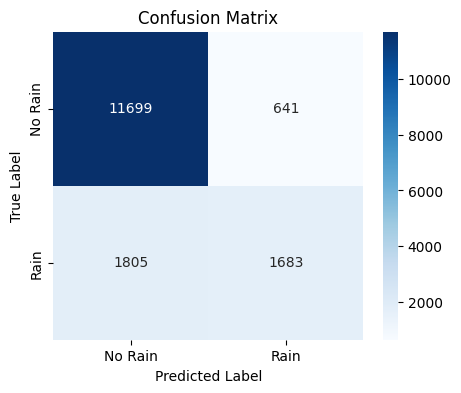

In [4]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"],
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Text(0.5, 0, 'False Positive Rate')

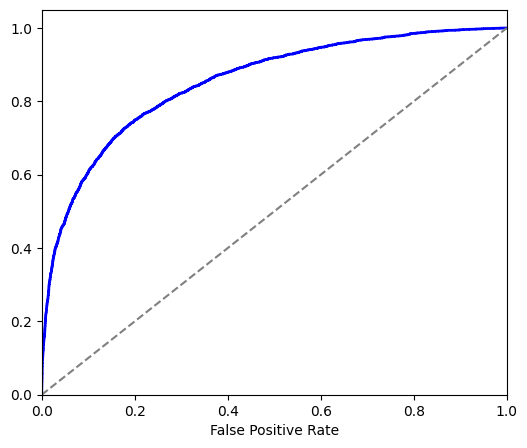

In [5]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")